# Mini Quant Fund V1

## Research Question
Which combination of quantitative factors provides the strongest risk-adjusted performance among a universe of large-cap Indian equities, and how robust is that performance across different portfolio-construction methods and market periods?

## Strategy Overview
This project develops and backtests a systematic multi-factor equity strategy using 30 liquid large-cap Indian stocks.

The model uses five factors:

1. Momentum
2. Low Risk
3. Quality
4. Value
5. Size

Stocks are ranked monthly using percentile-based factor scores.

The highest-ranked 10 stocks are selected and portfolios are constructed using three methods:

- Equal Weight
- Factor-Score Weight
- Sharpe-Optimized Weight

Performance is evaluated after transaction costs and compared with the NIFTY 50 benchmark.

The methodology uses point-in-time fundamental data with a reporting lag to reduce look-ahead bias and evaluates performance using training, validation, and out-of-sample periods.

The same frozen factor methodology will later also be used to generate a current model portfolio from the latest available data.

## Methodology

### Stock Universe

The strategy is tested on a fixed universe of 30 liquid large-cap Indian equities. The companies were selected to provide exposure across major sectors such as banking, information technology, energy, consumer goods, pharmaceuticals and industrials.

A fixed universe was used to keep the analysis consistent across the full sample period. This does, however, create survivorship bias because the exact historical composition of the large-cap universe was not reconstructed.

### Data

Historical stock-price data is collected at monthly frequency using the final trading day of each month.

Adjusted prices are used when calculating returns so that stock splits and other corporate actions do not artificially distort performance.

For valuation-related calculations such as P/E and market capitalisation, raw month-end prices are used instead.

Historical annual financial data is taken from Screener exports and includes:

- Net profit
- Equity share capital
- Reserves
- Shares outstanding

To reduce look-ahead bias, annual financial information is assumed to become available 90 days after the financial year-end. Until a newer report becomes available, the latest known fundamental value is carried forward.

### Factors

The model combines five quantitative factors.

**Momentum** measures the stock's trailing 12-month price performance. Higher momentum receives a higher score.

**Low Risk** is based on trailing 12-month volatility of monthly returns. Stocks with lower volatility receive higher scores.

**Quality** is measured using return on equity (ROE). Higher ROE receives a higher score.

**Value** is measured using the price-to-earnings ratio. Lower P/E stocks receive higher scores.

**Size** is measured using market capitalisation. Within the large-cap universe, smaller companies receive higher scores.

Each factor is converted into a cross-sectional percentile score every month. The five percentile scores are then equally weighted at 20% each to produce the final Factor Score.

### Stock Selection

At every monthly rebalance date, all eligible stocks are ranked by their Factor Score.

The 10 highest-ranked stocks are selected for the portfolio.

A deterministic tie-breaking rule is used so that identical factor scores always produce the same ranking.

### Portfolio Construction

Three portfolio-construction methods are compared.

**Equal Weight** assigns the same weight to each of the 10 selected stocks.

**Factor-Score Weight** allocates more weight to stocks with stronger overall factor scores.

**Sharpe-Optimized Weight** uses the previous 12 months of historical returns to choose long-only portfolio weights that maximise historical excess return relative to volatility.

Only information available at the rebalance date is used by the optimizer.

### Rebalancing and Transaction Costs

The portfolio is rebalanced monthly.

Turnover is calculated by comparing the new target portfolio with the previous portfolio after allowing its weights to drift with market returns.

A modelled all-in transaction-cost assumption of 0.25% per unit of turnover is applied to each rebalance. This is intended to approximate trading frictions rather than reproduce the exact cost of every historical trade.

### Benchmark and Risk-Free Rate

The strategy is compared with the NIFTY 50 index.

The risk-free rate is proxied using a monthly Indian short-term interest-rate series. Annualised observations are converted into monthly equivalents and matched to each backtest month.

This time-varying risk-free rate is used when calculating Sharpe ratios and when constructing the Sharpe-optimized portfolio.

### Evaluation Periods

The historical sample is divided into three periods:

- Training: 2020–2022
- Validation: 2023
- Out-of-sample testing: 2024

This separation is used to evaluate whether the strategy continues to perform after the initial development period rather than relying only on full-sample results.

Performance is evaluated using:

- CAGR
- Arithmetic annualised return
- Annualised volatility
- Sharpe ratio
- Maximum drawdown
- Portfolio turnover

In [ ]:
import os
import numpy as np
import pandas as pd
import yfinance as yf

from scipy.optimize import minimize

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

In [ ]:
# ============================================================
# CORE SETTINGS
# ============================================================

START_DATE = "2019-01-01"
END_DATE = "2025-01-01"

TOP_N = 10

REPORTING_LAG_DAYS = 90

OPTIMIZER_LOOKBACK_MONTHS = 12

TRAIN_START = "2020-01-01"
TRAIN_END = "2022-12-31"

VALIDATION_START = "2023-01-01"
VALIDATION_END = "2023-12-31"

TEST_START = "2024-01-01"
TEST_END = "2024-12-31"

In [ ]:
# ============================================================
# FINAL 30-STOCK UNIVERSE
# ============================================================

TICKERS = [
    "TCS.NS",
    "INFY.NS",
    "RELIANCE.NS",
    "HDFCBANK.NS",
    "ICICIBANK.NS",
    "SBIN.NS",
    "KOTAKBANK.NS",
    "AXISBANK.NS",
    "LT.NS",
    "BHARTIARTL.NS",
    "HINDUNILVR.NS",
    "ITC.NS",
    "ASIANPAINT.NS",
    "MARUTI.NS",
    "M&M.NS",
    "SUNPHARMA.NS",
    "DRREDDY.NS",
    "CIPLA.NS",
    "NTPC.NS",
    "POWERGRID.NS",
    "ONGC.NS",
    "COALINDIA.NS",
    "TITAN.NS",
    "BAJFINANCE.NS",
    "BAJAJFINSV.NS",
    "ULTRACEMCO.NS",
    "NESTLEIND.NS",
    "WIPRO.NS",
    "HCLTECH.NS",
    "TECHM.NS"
]

print("Universe size:", len(TICKERS))

Universe size: 30


In [ ]:
# ============================================================
# HISTORICAL PRICE DATA
# ============================================================

price_data = yf.download(
    TICKERS,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    repair=True,
    progress=False
)

close_prices = price_data["Close"].copy()

# Keep actual last trading day of each month
monthly_prices = (
    close_prices
    .groupby(close_prices.index.to_period("M"))
    .tail(1)
)

# Monthly returns
monthly_returns = (
    monthly_prices
    .pct_change(fill_method=None)
    * 100
)

# 12-month momentum
monthly_momentum = (
    monthly_prices
    .pct_change(
        periods=12,
        fill_method=None
    )
    * 100
)

# 12-month rolling monthly volatility
rolling_volatility = (
    monthly_returns
    .rolling(12)
    .std()
)

print("Price columns:", len(close_prices.columns))
print("Monthly observations:", len(monthly_prices))
print("\nDate range:")
print(monthly_prices.index.min(), "to", monthly_prices.index.max())

Price columns: 30
Monthly observations: 72

Date range:
2019-01-31 00:00:00 to 2024-12-31 00:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

SCREENER_FOLDER = "/content/drive/MyDrive/Mini_Quant_Fund/Screener_Files"

print(os.path.exists(SCREENER_FOLDER))
print(os.listdir(SCREENER_FOLDER)[:5])

In [ ]:
# ============================================================
# SCREENER FILE → TICKER MAP
# ============================================================

FILE_TICKER_MAP = {
    "TCS": "TCS.NS",
    "Infosys": "INFY.NS",
    "Reliance Industries": "RELIANCE.NS",
    "HDFC Bank": "HDFCBANK.NS",
    "ICICI Bank": "ICICIBANK.NS",
    "SBI": "SBIN.NS",
    "Kotak Mah. Bank": "KOTAKBANK.NS",
    "Axis Bank": "AXISBANK.NS",
    "Larsen & Toubro": "LT.NS",
    "Bharti Airtel": "BHARTIARTL.NS",
    "Hind. Unilever": "HINDUNILVR.NS",
    "ITC": "ITC.NS",
    "Asian Paints": "ASIANPAINT.NS",
    "Maruti Suzuki": "MARUTI.NS",
    "M & M": "M&M.NS",
    "Sun Pharma.Inds.": "SUNPHARMA.NS",
    "Dr Reddy's Labs": "DRREDDY.NS",
    "Cipla": "CIPLA.NS",
    "NTPC": "NTPC.NS",
    "Power Grid Corpn.": "POWERGRID.NS",
    "O N G C": "ONGC.NS",
    "Coal India": "COALINDIA.NS",
    "Titan Company": "TITAN.NS",
    "Bajaj Finance": "BAJFINANCE.NS",
    "Bajaj Finserv": "BAJAJFINSV.NS",
    "UltraTech Cem.": "ULTRACEMCO.NS",
    "Nestle India": "NESTLEIND.NS",
    "Wipro": "WIPRO.NS",
    "HCL Technologies": "HCLTECH.NS",
    "Tech Mahindra": "TECHM.NS"
}

In [ ]:
# ============================================================
# EXTRACT ANNUAL FUNDAMENTALS FROM SCREENER EXCEL
# ============================================================

def build_fundamental_factors(
    file_path,
    ticker,
    close_prices
):

    data_sheet = pd.read_excel(
        file_path,
        sheet_name="Data Sheet",
        header=None
    )

    # --------------------------------------------------------
    # FIND REQUIRED ROWS
    # --------------------------------------------------------

    report_row = data_sheet[
        data_sheet[0].astype(str).str.fullmatch(
            "Report Date",
            case=False,
            na=False
        )
    ].index[0]

    net_profit_row = data_sheet[
        data_sheet[0].astype(str).str.fullmatch(
            "Net profit",
            case=False,
            na=False
        )
    ].index[0]

    equity_capital_row = data_sheet[
        data_sheet[0].astype(str).str.fullmatch(
            "Equity Share Capital",
            case=False,
            na=False
        )
    ].index[0]

    reserves_row = data_sheet[
        data_sheet[0].astype(str).str.fullmatch(
            "Reserves",
            case=False,
            na=False
        )
    ].index[0]

    shares_row = data_sheet[
        data_sheet[0].astype(str).str.fullmatch(
            "No. of Equity Shares",
            case=False,
            na=False
        )
    ].index[0]

    adjusted_shares_row = data_sheet[
        data_sheet[0].astype(str).str.fullmatch(
            "Adjusted Equity Shares in Cr",
            case=False,
            na=False
        )
    ].index[0]


    # --------------------------------------------------------
    # EXTRACT VALUES
    # --------------------------------------------------------

    dates = pd.to_datetime(
        data_sheet.loc[report_row, 1:].values,
        errors="coerce"
    )

    net_profit = pd.to_numeric(
        data_sheet.loc[net_profit_row, 1:].values,
        errors="coerce"
    )

    equity_capital = pd.to_numeric(
        data_sheet.loc[equity_capital_row, 1:].values,
        errors="coerce"
    )

    reserves = pd.to_numeric(
        data_sheet.loc[reserves_row, 1:].values,
        errors="coerce"
    )

    shares_outstanding = pd.to_numeric(
        data_sheet.loc[shares_row, 1:].values,
        errors="coerce"
    )

    adjusted_shares_cr = pd.to_numeric(
        data_sheet.loc[adjusted_shares_row, 1:].values,
        errors="coerce"
    )


    # --------------------------------------------------------
    # BUILD CLEAN TABLE
    # --------------------------------------------------------

    df = pd.DataFrame({
        "Date": dates,
        "NetProfit": net_profit,
        "EquityShareCapital": equity_capital,
        "Reserves": reserves,
        "SharesOutstanding": shares_outstanding,
        "AdjustedSharesCr": adjusted_shares_cr
    })

    df = df.dropna(
        subset=["Date"]
    )


    # --------------------------------------------------------
    # QUALITY
    # --------------------------------------------------------

    df["Equity"] = (
        df["EquityShareCapital"]
        + df["Reserves"]
    )

    df["ROE"] = (
        df["NetProfit"]
        / df["Equity"]
    ) * 100


    # --------------------------------------------------------
    # EPS FOR VALUE FACTOR
    # --------------------------------------------------------

    df["EPS"] = (
        df["NetProfit"]
        / df["AdjustedSharesCr"]
    )


    # --------------------------------------------------------
    # INFORMATION AVAILABILITY
    # --------------------------------------------------------

    df["AvailableDate"] = (
        df["Date"]
        + pd.Timedelta(
            days=REPORTING_LAG_DAYS
        )
    )

    df["Stock"] = ticker


    return df[
        [
            "Date",
            "AvailableDate",
            "Stock",
            "ROE",
            "EPS",
            "SharesOutstanding"
        ]
    ]

In [ ]:
# ============================================================
# CONVERT ANNUAL FUNDAMENTALS TO MONTHLY POINT-IN-TIME VALUES
# ============================================================

def convert_to_monthly_fundamentals(
    annual_fundamentals,
    monthly_prices
):

    stock = annual_fundamentals["Stock"].iloc[0]

    monthly_df = pd.DataFrame({
        "Date": monthly_prices.index
    })

    monthly_df["Stock"] = stock

    monthly_df["ROE"] = np.nan
    monthly_df["EPS"] = np.nan
    monthly_df["SharesOutstanding"] = np.nan


    # --------------------------------------------------------
    # USE LATEST AVAILABLE FUNDAMENTALS AT EACH MONTH-END
    # --------------------------------------------------------

    for i, date in enumerate(monthly_df["Date"]):

        available_data = annual_fundamentals[
            annual_fundamentals["AvailableDate"] <= date
        ]

        if len(available_data) == 0:
            continue

        latest = (
            available_data
            .sort_values("AvailableDate")
            .iloc[-1]
        )

        monthly_df.loc[i, "ROE"] = latest["ROE"]
        monthly_df.loc[i, "EPS"] = latest["EPS"]
        monthly_df.loc[i, "SharesOutstanding"] = (
            latest["SharesOutstanding"]
        )


    # --------------------------------------------------------
    # CURRENT MONTH-END PRICE
    # --------------------------------------------------------

    monthly_df["MonthlyPrice"] = (
        raw_monthly_prices[stock]
        .reindex(monthly_df["Date"])
        .values
    )

    # --------------------------------------------------------
    # VALUE FACTOR
    # --------------------------------------------------------

    monthly_df["PE"] = (
        monthly_df["MonthlyPrice"]
        / monthly_df["EPS"]
    )


    # --------------------------------------------------------
    # SIZE FACTOR
    # --------------------------------------------------------

    monthly_df["MarketCap"] = (
        monthly_df["MonthlyPrice"]
        * monthly_df["SharesOutstanding"]
    )


    return monthly_df

In [ ]:
# ============================================================
# PROCESS ALL 30 SCREENER FILES
# ============================================================

all_monthly_fundamentals = []
worked = []
failed = []

for filename in os.listdir(SCREENER_FOLDER):

    if not filename.endswith(".xlsx"):
        continue

    file_path = os.path.join(SCREENER_FOLDER, filename)

    matched_name = None

    for company_name in FILE_TICKER_MAP:

        if company_name.lower() in filename.lower():
            matched_name = company_name
            break

    if matched_name is None:
        failed.append(
            (filename, "No ticker match")
        )
        continue

    ticker = FILE_TICKER_MAP[
        matched_name
    ]

    try:

        annual_df = build_fundamental_factors(
            file_path,
            ticker,
            close_prices
        )

        monthly_df = convert_to_monthly_fundamentals(
            annual_df,
            monthly_prices
        )

        all_monthly_fundamentals.append(
            monthly_df
        )

        worked.append(
            (filename, ticker)
        )

    except Exception as e:

        failed.append(
            (filename, str(e))
        )


# ============================================================
# COMBINE ALL STOCKS
# ============================================================

combined_fundamentals = pd.concat(
    all_monthly_fundamentals,
    ignore_index=True
)

# Remove accidental duplicate uploads
combined_fundamentals = (
    combined_fundamentals
    .drop_duplicates(
        subset=["Date", "Stock"],
        keep="first"
    )
    .reset_index(drop=True)
)


# ============================================================
# CHECK RESULTS
# ============================================================

print(
    "Unique stocks processed:",
    combined_fundamentals["Stock"].nunique()
)

print(
    "Duplicate stock-date rows:",
    combined_fundamentals.duplicated(
        subset=["Date", "Stock"]
    ).sum()
)

print("\nFailed files:")

for item in failed:
    print(item)

Unique stocks processed: 30
Duplicate stock-date rows: 0

Failed files:


In [ ]:
# ============================================================
# BUILD FULL 5-FACTOR DATASET
# ============================================================

factor_rows = []

for ticker in combined_fundamentals["Stock"].unique():

    stock_df = combined_fundamentals[
        combined_fundamentals["Stock"] == ticker
    ].copy()

    # Momentum
    stock_df["Momentum"] = (
        monthly_momentum[ticker]
        .reindex(stock_df["Date"])
        .values
    )

    # Low Risk input
    stock_df["Volatility"] = (
        rolling_volatility[ticker]
        .reindex(stock_df["Date"])
        .values
    )

    factor_rows.append(stock_df)


all_factor_data = pd.concat(
    factor_rows,
    ignore_index=True
)

In [ ]:
# ============================================================
# SCORE ALL 5 FACTORS CROSS-SECTIONALLY EACH MONTH
# ============================================================

def score_5_factors(month_df):

    scored = month_df.copy()

    # Higher Momentum = better
    scored["MomentumScore"] = (
        scored["Momentum"]
        .rank(
            ascending=True,
            pct=True
        )
    )

    # Lower Volatility = better
    scored["LowRiskScore"] = (
        scored["Volatility"]
        .rank(
            ascending=False,
            pct=True
        )
    )

    # Higher ROE = better
    scored["QualityScore"] = (
        scored["ROE"]
        .rank(
            ascending=True,
            pct=True
        )
    )

    # Lower P/E = better
    scored["ValueScore"] = (
        scored["PE"]
        .rank(
            ascending=False,
            pct=True
        )
    )

    # Smaller Market Cap = better
    scored["SizeScore"] = (
        scored["MarketCap"]
        .rank(
            ascending=False,
            pct=True
        )
    )

    # Equal-weight 5-factor score
    scored["FactorScore"] = (
        scored[
            [
                "MomentumScore",
                "LowRiskScore",
                "QualityScore",
                "ValueScore",
                "SizeScore"
            ]
        ].mean(axis=1)
    )

    return scored

In [ ]:
# ============================================================
# BUILD MONTHLY 5-FACTOR RANKINGS
# ============================================================

scored_months = []

for date in sorted(
    all_factor_data["Date"].unique()
):

    month_df = (
        all_factor_data[
            all_factor_data["Date"] == date
        ]
        .copy()
    )

    # Require all 5 factors
    month_df = month_df.dropna(
        subset=[
            "Momentum",
            "Volatility",
            "ROE",
            "PE",
            "MarketCap"
        ]
    )

    if len(month_df) == 0:
        continue

    scored = score_5_factors(
        month_df
    )

    scored_months.append(
        scored
    )


scored_stocks = pd.concat(
    scored_months,
    ignore_index=True
)

print(
    "Stocks scored:",
    scored_stocks["Stock"].nunique()
)

print(
    "Total scored rows:",
    len(scored_stocks)
)

# ============================================================
# BUILD MONTHLY 5-FACTOR RANKINGS
# ============================================================

scored_months = []

for date in sorted(
    all_factor_data["Date"].unique()
):

    month_df = (
        all_factor_data[
            all_factor_data["Date"] == date
        ]
        .copy()
    )

    # Require all 5 factors
    month_df = month_df.dropna(
        subset=[
            "Momentum",
            "Volatility",
            "ROE",
            "PE",
            "MarketCap"
        ]
    )

    if len(month_df) == 0:
        continue

    scored = score_5_factors(
        month_df
    )

    scored_months.append(
        scored
    )


scored_stocks = pd.concat(
    scored_months,
    ignore_index=True
)

print(
    "Stocks scored:",
    scored_stocks["Stock"].nunique()
)

print(
    "Total scored rows:",
    len(scored_stocks)
)

sample_date = pd.Timestamp("2020-07-31")

sample_ranking = (
    scored_stocks[
        scored_stocks["Date"] == sample_date
    ]
    .sort_values(
        "FactorScore",
        ascending=False
    )
)

print(
    sample_ranking[
        [
            "Stock",
            "MomentumScore",
            "LowRiskScore",
            "QualityScore",
            "ValueScore",
            "SizeScore",
            "FactorScore"
        ]
    ].head(10)
)

Stocks scored: 30
Total scored rows: 1797
Stocks scored: 30
Total scored rows: 1797
             Stock  MomentumScore  LowRiskScore  QualityScore  ValueScore  SizeScore  FactorScore
208   NESTLEIND.NS       0.900000      0.933333      1.000000    0.066667   1.000000     0.780000
182   POWERGRID.NS       0.333333      1.000000      0.633333    0.900000   0.833333     0.740000
205   COALINDIA.NS       0.166667      0.866667      0.933333    0.966667   0.700000     0.726667
198     DRREDDY.NS       0.966667      0.700000      0.466667    0.300000   0.933333     0.673333
183       TECHM.NS       0.600000      0.466667      0.700000    0.733333   0.766667     0.653333
188       WIPRO.NS       0.533333      0.600000      0.666667    0.700000   0.666667     0.633333
194  ASIANPAINT.NS       0.666667      0.966667      0.866667    0.200000   0.400000     0.620000
197  HINDUNILVR.NS       0.800000      0.900000      0.966667    0.100000   0.100000     0.573333
206  BHARTIARTL.NS       0.933333 

In [ ]:
# ============================================================
# SELECT TOP 10 STOCKS EACH MONTH
# DETERMINISTIC TIE-BREAK
# ============================================================

top10_each_month = (
    scored_stocks
    .sort_values(
        [
            "Date",
            "FactorScore",
            "MomentumScore",
            "Stock"
        ],
        ascending=[
            True,
            False,
            False,
            True
        ]
    )
    .groupby("Date")
    .head(TOP_N)
    .copy()
)

rebalance_dates = sorted(
    top10_each_month["Date"].unique()
)

all_stocks = sorted(
    scored_stocks["Stock"].unique()
)

print("Rebalance months:", len(rebalance_dates))
print("Stocks in universe:", len(all_stocks))

Rebalance months: 60
Stocks in universe: 30


In [ ]:
# ============================================================
# BUILD PORTFOLIO WEIGHTS
# ============================================================

equal_weight_rows = []
factor_weight_rows = []
sharpe_weight_rows = []

for date in rebalance_dates:

    selected = top10_each_month[
        top10_each_month["Date"] == date
    ].copy()

    selected_stocks = selected["Stock"].tolist()

    # --------------------------------------------------------
    # 1. EQUAL WEIGHT
    # --------------------------------------------------------

    eq = pd.Series(
        0.0,
        index=all_stocks
    )

    eq[selected_stocks] = (
        1 / len(selected_stocks)
    )

    equal_weight_rows.append(eq)


    # --------------------------------------------------------
    # 2. FACTOR-SCORE WEIGHT
    # --------------------------------------------------------

    fw = pd.Series(
        0.0,
        index=all_stocks
    )

    scores = (
        selected
        .set_index("Stock")["FactorScore"]
    )

    fw[selected_stocks] = (
        scores / scores.sum()
    )

    factor_weight_rows.append(fw)


    # --------------------------------------------------------
    # 3. SHARPE-OPTIMIZED WEIGHT
    # --------------------------------------------------------

    sh = pd.Series(
        0.0,
        index=all_stocks
    )

    historical_returns = (
        monthly_returns
        .loc[:date, selected_stocks]
        .tail(OPTIMIZER_LOOKBACK_MONTHS)
        .dropna()
    )

    if len(historical_returns) < 6:

        sh[selected_stocks] = (
            1 / len(selected_stocks)
        )

    else:

        def negative_sharpe(weights):

            portfolio_returns = (
                historical_returns @ weights
            )

            annual_return = (
                portfolio_returns.mean() * 12
            )

            annual_volatility = (
                portfolio_returns.std()
                * np.sqrt(12)
            )

            if annual_volatility == 0:
                return 999

            # Temporary optimizer objective:
            # excess return adjustment will be made
            # using the historical risk-free setup later
            return -(
                annual_return
                / annual_volatility
            )


        n = len(selected_stocks)

        starting_weights = np.repeat(
            1 / n,
            n
        )

        bounds = [
            (0, 1)
            for _ in range(n)
        ]

        constraints = {
            "type": "eq",
            "fun": lambda w: np.sum(w) - 1
        }

        result = minimize(
            negative_sharpe,
            starting_weights,
            bounds=bounds,
            constraints=constraints
        )

        if result.success:
            sh[selected_stocks] = result.x
        else:
            sh[selected_stocks] = (
                1 / len(selected_stocks)
            )

    sharpe_weight_rows.append(sh)


equal_weights = pd.DataFrame(
    equal_weight_rows,
    index=rebalance_dates
)

factor_weights = pd.DataFrame(
    factor_weight_rows,
    index=rebalance_dates
)

sharpe_weights = pd.DataFrame(
    sharpe_weight_rows,
    index=rebalance_dates
)

In [ ]:
# ============================================================
# BACKTEST PORTFOLIO WEIGHTS
# ============================================================

TRANSACTION_COST_RATE = 0.0025

def backtest_weights(
    weights_df,
    monthly_returns,
    transaction_cost_rate=TRANSACTION_COST_RATE
):

    records = []

    previous_target_weights = None

    for i, date in enumerate(weights_df.index[:-1]):

        next_date = weights_df.index[i + 1]

        target_weights = weights_df.loc[date].copy()

        # ----------------------------------------------------
        # NEXT-MONTH STOCK RETURNS
        # ----------------------------------------------------

        next_stock_returns = (
            monthly_returns
            .loc[next_date]
            .reindex(target_weights.index)
        )

        # Safety check
        selected = target_weights[
            target_weights > 0
        ].index

        if next_stock_returns.loc[selected].isna().any():

            missing = (
                next_stock_returns
                .loc[selected]
                .loc[
                    next_stock_returns.loc[selected].isna()
                ]
                .index
                .tolist()
            )

            raise ValueError(
                f"Missing next-month returns for {missing} at {next_date}"
            )

        # ----------------------------------------------------
        # TURNOVER
        # ----------------------------------------------------

        if previous_target_weights is None:

            turnover = 1.0

        else:

            current_month_returns = (
                monthly_returns
                .loc[date]
                .reindex(previous_target_weights.index)
                .fillna(0)
                / 100
            )

            drifted_weights = (
                previous_target_weights
                * (1 + current_month_returns)
            )

            if drifted_weights.sum() != 0:

                drifted_weights = (
                    drifted_weights
                    / drifted_weights.sum()
                )

            turnover = (
                0.5
                * np.abs(
                    target_weights
                    - drifted_weights
                ).sum()
            )

        # ----------------------------------------------------
        # GROSS PORTFOLIO RETURN
        # ----------------------------------------------------

        gross_return = (
            target_weights
            * next_stock_returns
        ).sum()

        # ----------------------------------------------------
        # TRANSACTION COST
        # ----------------------------------------------------

        transaction_cost = (
            turnover
            * transaction_cost_rate
            * 100
        )

        net_return = (
            gross_return
            - transaction_cost
        )

        records.append({
            "RebalanceDate": date,
            "ReturnDate": next_date,
            "GrossReturn": gross_return,
            "Turnover": turnover,
            "TransactionCost": transaction_cost,
            "NetReturn": net_return
        })

        previous_target_weights = (
            target_weights.copy()
        )

    return pd.DataFrame(records)

In [ ]:
# ============================================================
# RUN BACKTESTS
# ============================================================

equal_backtest = backtest_weights(
    equal_weights,
    monthly_returns
)

factor_backtest = backtest_weights(
    factor_weights,
    monthly_returns
)

sharpe_backtest = backtest_weights(
    sharpe_weights,
    monthly_returns
)

print("Equal Weight months:", len(equal_backtest))
print("Factor Weight months:", len(factor_backtest))
print("Sharpe Optimized months:", len(sharpe_backtest))

Equal Weight months: 59
Factor Weight months: 59
Sharpe Optimized months: 59


In [ ]:
# ============================================================
# NIFTY 50 BENCHMARK
# ============================================================

nifty_data = yf.download(
    "^NSEI",
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    repair=True,
    progress=False
)

nifty_close = nifty_data["Close"].copy()

# Keep actual last trading day of each month
nifty_monthly = (
    nifty_close
    .groupby(nifty_close.index.to_period("M"))
    .tail(1)
)

nifty_monthly_returns = (
    nifty_monthly
    .pct_change(fill_method=None)
    * 100
)

print("NIFTY monthly observations:", len(nifty_monthly_returns))
print(
    "Date range:",
    nifty_monthly_returns.index.min(),
    "to",
    nifty_monthly_returns.index.max()
)

NIFTY monthly observations: 72
Date range: 2019-01-31 00:00:00 to 2024-12-31 00:00:00


In [ ]:
# ============================================================
# ALIGN NIFTY WITH STRATEGY RETURN DATES
# ============================================================

strategy_return_dates = pd.to_datetime(
    factor_backtest["ReturnDate"]
)

nifty_aligned = (
    nifty_monthly_returns
    .reindex(strategy_return_dates)
)

nifty_backtest = pd.DataFrame({
    "ReturnDate": strategy_return_dates,
    "NetReturn": nifty_aligned.values.flatten()
})

print(nifty_backtest.head())
print("\nMissing NIFTY returns:", nifty_backtest["NetReturn"].isna().sum())

  ReturnDate  NetReturn
0 2020-02-28  -6.356322
1 2020-03-31 -23.246368
2 2020-04-30  14.680008
3 2020-05-29  -2.835734
4 2020-06-30   7.534209

Missing NIFTY returns: 0


In [ ]:
# ============================================================
# HISTORICAL RISK-FREE RATE
# INDIA 3-MONTH / 90-DAY RATE
# ============================================================

import pandas as pd

rf_url = (
    "https://fred.stlouisfed.org/graph/fredgraph.csv"
    "?id=INDIR3TIB01STM"
)

risk_free = pd.read_csv(rf_url)

risk_free.columns = [
    "Date",
    "RF_Annual"
]

risk_free["Date"] = pd.to_datetime(
    risk_free["Date"]
)

risk_free["RF_Annual"] = pd.to_numeric(
    risk_free["RF_Annual"],
    errors="coerce"
)

risk_free = (
    risk_free
    .dropna()
    .query(
        "Date >= '2019-01-01' and Date <= '2024-12-31'"
    )
    .reset_index(drop=True)
)

print(risk_free.head())
print(risk_free.tail())

print(
    "\nObservations:",
    len(risk_free)
)

        Date  RF_Annual
0 2019-01-01   6.635850
1 2019-02-01   6.480550
2 2019-03-01   6.356300
3 2019-04-01   6.304575
4 2019-05-01   6.372880
         Date  RF_Annual
67 2024-08-01   6.639380
68 2024-09-01   6.638150
69 2024-10-01   6.458775
70 2024-11-01   6.469160
71 2024-12-01   6.474500

Observations: 72


In [ ]:
# ============================================================
# CONVERT RISK-FREE DATES TO MONTH-END
# ============================================================

risk_free["Date"] = (
    risk_free["Date"]
    .dt.to_period("M")
    .dt.to_timestamp("M")
)

print(risk_free.head())

        Date  RF_Annual
0 2019-01-31   6.635850
1 2019-02-28   6.480550
2 2019-03-31   6.356300
3 2019-04-30   6.304575
4 2019-05-31   6.372880


In [ ]:
# ============================================================
# MONTHLY RISK-FREE RETURN
# ============================================================

risk_free["RF_Monthly"] = (
    (
        1
        + risk_free["RF_Annual"] / 100
    ) ** (1 / 12)
    - 1
) * 100

print(
    risk_free[
        [
            "Date",
            "RF_Annual",
            "RF_Monthly"
        ]
    ].head(10)
)

        Date  RF_Annual  RF_Monthly
0 2019-01-31   6.635850    0.536849
1 2019-02-28   6.480550    0.524639
2 2019-03-31   6.356300    0.514859
3 2019-04-30   6.304575    0.510785
4 2019-05-31   6.372880    0.516165
5 2019-06-30   6.004775    0.487132
6 2019-07-31   5.829275    0.473258
7 2019-08-31   5.488940    0.446292
8 2019-09-30   5.344725    0.434842
9 2019-10-31   5.180050    0.421749


In [ ]:
# ============================================================
# ALIGN RISK-FREE SERIES BY MONTH
# ============================================================

rf_by_month = (
    risk_free
    .assign(
        Month=risk_free["Date"].dt.to_period("M")
    )
    .set_index("Month")["RF_Monthly"]
)

strategy_months = (
    pd.Series(strategy_return_dates)
    .dt.to_period("M")
)

risk_free_aligned = (
    strategy_months
    .map(rf_by_month)
)

risk_free_aligned.index = strategy_return_dates

print(
    "Risk-free observations:",
    risk_free_aligned.notna().sum()
)

print(
    "Missing risk-free months:",
    risk_free_aligned.isna().sum()
)

print(risk_free_aligned.head())

Risk-free observations: 59
Missing risk-free months: 0
ReturnDate
2020-02-28    0.414382
2020-03-31    0.406139
2020-04-30    0.338148
2020-05-29    0.280890
2020-06-30    0.271818
Name: ReturnDate, dtype: float64


In [ ]:
# ============================================================
# REBUILD SHARPE-OPTIMIZED WEIGHTS
# USING HISTORICAL MONTHLY RISK-FREE RATE
# ============================================================

sharpe_weight_rows = []

for date in rebalance_dates:

    selected = top10_each_month[
        top10_each_month["Date"] == date
    ].copy()

    selected_stocks = selected["Stock"].tolist()

    sh = pd.Series(
        0.0,
        index=all_stocks
    )

    historical_returns = (
        monthly_returns
        .loc[:date, selected_stocks]
        .tail(OPTIMIZER_LOOKBACK_MONTHS)
        .dropna()
    )

    if len(historical_returns) < 6:

        sh[selected_stocks] = (
            1 / len(selected_stocks)
        )

    else:

        # ----------------------------------------------------
        # MATCH HISTORICAL RETURNS WITH MONTHLY RF RATE
        # ----------------------------------------------------

        historical_months = (
            historical_returns.index
            .to_period("M")
        )

        historical_rf = pd.Series(
            historical_months.map(rf_by_month),
            index=historical_returns.index
        )

        # Only use months where RF data exists
        valid_dates = historical_rf.dropna().index

        historical_returns_clean = (
            historical_returns.loc[valid_dates]
        )

        historical_rf_clean = (
            historical_rf.loc[valid_dates]
        )

        # ----------------------------------------------------
        # PROPER SHARPE OBJECTIVE
        # ----------------------------------------------------

        def negative_sharpe(weights):

            portfolio_returns = (
                historical_returns_clean
                @ weights
            )

            monthly_excess_returns = (
                portfolio_returns
                - historical_rf_clean
            )

            annual_excess_return = (
                monthly_excess_returns.mean()
                * 12
            )

            annual_volatility = (
                portfolio_returns.std()
                * np.sqrt(12)
            )

            if (
                annual_volatility == 0
                or np.isnan(annual_volatility)
            ):
                return 999

            sharpe = (
                annual_excess_return
                / annual_volatility
            )

            return -sharpe


        n = len(selected_stocks)

        starting_weights = np.repeat(
            1 / n,
            n
        )

        bounds = [
            (0, 1)
            for _ in range(n)
        ]

        constraints = {
            "type": "eq",
            "fun": lambda w: np.sum(w) - 1
        }

        result = minimize(
            negative_sharpe,
            starting_weights,
            bounds=bounds,
            constraints=constraints
        )

        if result.success:

            sh[selected_stocks] = result.x

        else:

            sh[selected_stocks] = (
                1 / len(selected_stocks)
            )

    sharpe_weight_rows.append(sh)


sharpe_weights = pd.DataFrame(
    sharpe_weight_rows,
    index=rebalance_dates
)

print(
    "Sharpe portfolios built:",
    len(sharpe_weights)
)

Sharpe portfolios built: 60


In [ ]:
sharpe_backtest = backtest_weights(
    sharpe_weights,
    monthly_returns
)

print(
    "Sharpe Optimized months:",
    len(sharpe_backtest)
)

Sharpe Optimized months: 59


In [ ]:
# ============================================================
# PERFORMANCE METRICS
# ============================================================

def calculate_metrics(
    backtest_df,
    rf_by_month,
    include_turnover=True
):

    df = backtest_df.copy()

    returns = (
        df["NetReturn"]
        .astype(float)
    )

    dates = pd.to_datetime(
        df["ReturnDate"]
    )

    # --------------------------------------------------------
    # ANNUALIZED ARITHMETIC RETURN
    # --------------------------------------------------------

    arithmetic_return = (
        returns.mean()
        * 12
    )

    # --------------------------------------------------------
    # CAGR
    # --------------------------------------------------------

    cumulative_growth = (
        1 + returns / 100
    ).prod()

    years = (
        len(returns)
        / 12
    )

    cagr = (
        cumulative_growth ** (1 / years)
        - 1
    ) * 100

    # --------------------------------------------------------
    # VOLATILITY
    # --------------------------------------------------------

    annual_volatility = (
        returns.std()
        * np.sqrt(12)
    )

    # --------------------------------------------------------
    # HISTORICAL MONTHLY RISK-FREE RATE
    # --------------------------------------------------------

    months = (
        dates
        .dt.to_period("M")
    )

    rf_monthly = pd.Series(
        months.map(rf_by_month)
    )

    if rf_monthly.isna().any():

        missing_months = (
            months[
                rf_monthly.isna()
            ]
            .astype(str)
            .tolist()
        )

        raise ValueError(
            f"Missing risk-free values for: {missing_months}"
        )

    # --------------------------------------------------------
    # PROPER SHARPE RATIO
    # --------------------------------------------------------

    monthly_excess_returns = (
        returns.reset_index(drop=True)
        - rf_monthly.reset_index(drop=True)
    )

    annual_excess_return = (
        monthly_excess_returns.mean()
        * 12
    )

    sharpe_ratio = (
        annual_excess_return
        / annual_volatility
    )

    # --------------------------------------------------------
    # MAXIMUM DRAWDOWN
    # --------------------------------------------------------

    wealth = (
        1 + returns / 100
    ).cumprod()

    running_peak = (
        wealth.cummax()
    )

    drawdown = (
        wealth / running_peak
        - 1
    )

    max_drawdown = (
        drawdown.min()
        * 100
    )

    # --------------------------------------------------------
    # TURNOVER
    # --------------------------------------------------------

    if (
        include_turnover
        and "Turnover" in df.columns
    ):

        avg_turnover = (
            df["Turnover"].mean()
            * 100
        )

    else:

        avg_turnover = np.nan


    return {
        "Arithmetic Return (%)": arithmetic_return,
        "CAGR (%)": cagr,
        "Volatility (%)": annual_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown (%)": max_drawdown,
        "Avg Monthly Turnover (%)": avg_turnover
    }

In [ ]:
# ============================================================
# FULL-PERIOD PERFORMANCE COMPARISON
# ============================================================

equal_metrics = calculate_metrics(
    equal_backtest,
    rf_by_month
)

factor_metrics = calculate_metrics(
    factor_backtest,
    rf_by_month
)

sharpe_metrics = calculate_metrics(
    sharpe_backtest,
    rf_by_month
)

nifty_metrics = calculate_metrics(
    nifty_backtest,
    rf_by_month,
    include_turnover=False
)

comparison_table = pd.DataFrame(
    {
        "Equal Weight": equal_metrics,
        "Factor Score": factor_metrics,
        "Sharpe Optimized": sharpe_metrics,
        "NIFTY 50": nifty_metrics
    }
).T

comparison_table = comparison_table.round(3)

comparison_table

,Arithmetic Return (%),CAGR (%),Volatility (%),Sharpe Ratio,Max Drawdown (%),Avg Monthly Turnover (%)
Equal Weight,23.243,24.171,16.818,1.083,-15.418,16.227
Factor Score,23.901,25.034,16.551,1.141,-14.671,15.288
Sharpe Optimized,18.237,18.317,16.428,0.804,-15.072,34.825
NIFTY 50,15.771,14.865,18.912,0.568,-23.246,NaN


In [ ]:
print("Equal months:", len(equal_backtest))
print("Factor months:", len(factor_backtest))
print("Sharpe months:", len(sharpe_backtest))
print("NIFTY months:", len(nifty_backtest))

print("\nMissing values:")
print(comparison_table.isna().sum())

Equal months: 59
Factor months: 59
Sharpe months: 59
NIFTY months: 59

Missing values:
Arithmetic Return (%)       0
CAGR (%)                    0
Volatility (%)              0
Sharpe Ratio                0
Max Drawdown (%)            0
Avg Monthly Turnover (%)    1
dtype: int64


In [ ]:
# ============================================================
# SPLIT BACKTEST BY PERIOD
# ============================================================

def filter_period(
    backtest_df,
    start_date,
    end_date
):

    df = backtest_df.copy()

    df["ReturnDate"] = pd.to_datetime(
        df["ReturnDate"]
    )

    mask = (
        (df["ReturnDate"] >= pd.Timestamp(start_date))
        &
        (df["ReturnDate"] <= pd.Timestamp(end_date))
    )

    return df.loc[mask].copy()

# ============================================================
# TRAIN / VALIDATION / OUT-OF-SAMPLE
# ============================================================

periods = {
    "Training 2020-2022": (
        TRAIN_START,
        TRAIN_END
    ),

    "Validation 2023": (
        VALIDATION_START,
        VALIDATION_END
    ),

    "Out-of-Sample 2024": (
        TEST_START,
        TEST_END
    )
}

results_by_period = {}

for period_name, (start_date, end_date) in periods.items():

    equal_period = filter_period(
        equal_backtest,
        start_date,
        end_date
    )

    factor_period = filter_period(
        factor_backtest,
        start_date,
        end_date
    )

    sharpe_period = filter_period(
        sharpe_backtest,
        start_date,
        end_date
    )

    nifty_period = filter_period(
        nifty_backtest,
        start_date,
        end_date
    )

    period_table = pd.DataFrame({
        "Equal Weight": calculate_metrics(
            equal_period,
            rf_by_month
        ),

        "Factor Score": calculate_metrics(
            factor_period,
            rf_by_month
        ),

        "Sharpe Optimized": calculate_metrics(
            sharpe_period,
            rf_by_month
        ),

        "NIFTY 50": calculate_metrics(
            nifty_period,
            rf_by_month,
            include_turnover=False
        )
    }).T

    results_by_period[
        period_name
    ] = period_table.round(3)


for period_name, table in results_by_period.items():

    print("\n" + "=" * 80)
    print(period_name)
    print("=" * 80)

    display(table)


Training 2020-2022


,Arithmetic Return (%),CAGR (%),Volatility (%),Sharpe Ratio,Max Drawdown (%),Avg Monthly Turnover (%)
Equal Weight,21.289,21.432,18.692,0.927,-15.418,15.475
Factor Score,21.914,22.269,18.310,0.980,-14.671,14.628
Sharpe Optimized,13.494,12.679,17.804,0.535,-15.072,36.440
NIFTY 50,16.963,15.269,22.861,0.569,-23.246,NaN



Validation 2023


,Arithmetic Return (%),CAGR (%),Volatility (%),Sharpe Ratio,Max Drawdown (%),Avg Monthly Turnover (%)
Equal Weight,37.539,43.812,12.135,2.550,-0.846,9.095
Factor Score,38.025,44.496,12.107,2.596,-0.999,8.657
Sharpe Optimized,37.649,43.682,13.785,2.253,-3.762,21.632
NIFTY 50,19.064,20.028,12.194,1.023,-3.413,NaN



Out-of-Sample 2024


,Arithmetic Return (%),CAGR (%),Volatility (%),Sharpe Ratio,Max Drawdown (%),Avg Monthly Turnover (%)
Equal Weight,14.644,14.419,15.419,0.525,-10.180,25.554
Factor Score,15.574,15.486,15.363,0.587,-10.173,23.843
Sharpe Optimized,12.660,12.339,14.495,0.422,-8.693,43.310
NIFTY 50,9.002,8.805,10.783,0.227,-8.392,NaN


In [ ]:
# ============================================================
# ROBUSTNESS TESTS
# ============================================================

robustness_results = {}

# ============================================================
# 1. TOP-N ROBUSTNESS
# ============================================================

top_n_results = []

for test_top_n in [8, 10, 12]:

    test_selection = (
        scored_stocks
        .sort_values(
            [
                "Date",
                "FactorScore",
                "MomentumScore",
                "Stock"
            ],
            ascending=[
                True,
                False,
                False,
                True
            ]
        )
        .groupby("Date")
        .head(test_top_n)
        .copy()
    )

    test_weights_rows = []

    for date in sorted(
        test_selection["Date"].unique()
    ):

        selected = test_selection[
            test_selection["Date"] == date
        ]

        weights = pd.Series(
            0.0,
            index=all_stocks
        )

        scores = (
            selected
            .set_index("Stock")["FactorScore"]
        )

        weights.loc[scores.index] = (
            scores / scores.sum()
        )

        test_weights_rows.append(weights)

    test_weights = pd.DataFrame(
        test_weights_rows,
        index=sorted(
            test_selection["Date"].unique()
        )
    )

    test_backtest = backtest_weights(
        test_weights,
        monthly_returns
    )

    metrics = calculate_metrics(
        test_backtest,
        rf_by_month
    )

    metrics["Top N"] = test_top_n

    top_n_results.append(metrics)


top_n_table = (
    pd.DataFrame(top_n_results)
    .set_index("Top N")
    .round(3)
)

robustness_results["Top N"] = top_n_table


# ============================================================
# 2. TRANSACTION COST ROBUSTNESS
# ============================================================

cost_results = []

for test_cost in [
    0.0010,
    0.0025,
    0.0040
]:

    test_backtest = backtest_weights(
        factor_weights,
        monthly_returns,
        transaction_cost_rate=test_cost
    )

    metrics = calculate_metrics(
        test_backtest,
        rf_by_month
    )

    metrics["Transaction Cost (%)"] = (
        test_cost * 100
    )

    cost_results.append(metrics)


cost_table = (
    pd.DataFrame(cost_results)
    .set_index("Transaction Cost (%)")
    .round(3)
)

robustness_results[
    "Transaction Costs"
] = cost_table


# ============================================================
# 3. FACTOR-WEIGHT ROBUSTNESS
# ============================================================

factor_weight_results = []

# ------------------------------------------------------------
# PRIMARY SPECIFICATION
# Use the canonical Factor Score backtest directly
# ------------------------------------------------------------

primary_metrics = calculate_metrics(
    factor_backtest,
    rf_by_month
)

primary_metrics["Scheme"] = "Equal 20/20/20/20/20"

factor_weight_results.append(
    primary_metrics
)


# ------------------------------------------------------------
# ALTERNATIVE FACTOR-WEIGHT SCHEMES
# ------------------------------------------------------------

alternative_schemes = {

    "Momentum Heavy": {
        "MomentumScore": 0.40,
        "LowRiskScore": 0.15,
        "QualityScore": 0.15,
        "ValueScore": 0.15,
        "SizeScore": 0.15
    },

    "Quality Value Heavy": {
        "MomentumScore": 0.15,
        "LowRiskScore": 0.15,
        "QualityScore": 0.30,
        "ValueScore": 0.30,
        "SizeScore": 0.10
    },

    "Risk Quality Heavy": {
        "MomentumScore": 0.15,
        "LowRiskScore": 0.30,
        "QualityScore": 0.30,
        "ValueScore": 0.15,
        "SizeScore": 0.10
    }
}


for scheme_name, scheme in alternative_schemes.items():

    scheme_data = scored_stocks.copy()

    scheme_data["WeightedFactorScore"] = 0.0

    for factor_name, weight in scheme.items():

        scheme_data["WeightedFactorScore"] += (
            scheme_data[factor_name]
            * weight
        )

    # Deterministic selection
    scheme_selection = (
        scheme_data
        .sort_values(
            [
                "Date",
                "WeightedFactorScore",
                "MomentumScore",
                "Stock"
            ],
            ascending=[
                True,
                False,
                False,
                True
            ]
        )
        .groupby("Date")
        .head(TOP_N)
        .copy()
    )

    scheme_weights_rows = []

    scheme_dates = sorted(
        scheme_selection["Date"].unique()
    )

    for date in scheme_dates:

        selected = (
            scheme_selection[
                scheme_selection["Date"] == date
            ]
            .copy()
        )

        weights = pd.Series(
            0.0,
            index=all_stocks
        )

        scores = (
            selected
            .set_index("Stock")[
                "WeightedFactorScore"
            ]
        )

        weights.loc[scores.index] = (
            scores / scores.sum()
        )

        scheme_weights_rows.append(
            weights
        )

    scheme_weights = pd.DataFrame(
        scheme_weights_rows,
        index=scheme_dates
    )

    scheme_backtest = backtest_weights(
        scheme_weights,
        monthly_returns
    )

    metrics = calculate_metrics(
        scheme_backtest,
        rf_by_month
    )

    metrics["Scheme"] = scheme_name

    factor_weight_results.append(
        metrics
    )


factor_weight_table = (
    pd.DataFrame(
        factor_weight_results
    )
    .set_index("Scheme")
    .round(3)
)

robustness_results[
    "Factor Weights"
] = factor_weight_table

display(factor_weight_table)# ============================================================
# 4. YEAR-BY-YEAR PERFORMANCE
# ============================================================

yearly_results = []

for year in [
    2020,
    2021,
    2022,
    2023,
    2024
]:

    start = f"{year}-01-01"
    end = f"{year}-12-31"

    strategy_year = filter_period(
        factor_backtest,
        start,
        end
    )

    nifty_year = filter_period(
        nifty_backtest,
        start,
        end
    )

    strategy_metrics = (
        calculate_metrics(
            strategy_year,
            rf_by_month
        )
    )

    nifty_metrics_year = (
        calculate_metrics(
            nifty_year,
            rf_by_month,
            include_turnover=False
        )
    )

    yearly_results.append({
        "Year": year,

        "Strategy CAGR (%)":
            strategy_metrics["CAGR (%)"],

        "Strategy Sharpe":
            strategy_metrics["Sharpe Ratio"],

        "Strategy Volatility (%)":
            strategy_metrics["Volatility (%)"],

        "Strategy Max Drawdown (%)":
            strategy_metrics[
                "Max Drawdown (%)"
            ],

        "NIFTY CAGR (%)":
            nifty_metrics_year["CAGR (%)"],

        "NIFTY Sharpe":
            nifty_metrics_year[
                "Sharpe Ratio"
            ],

        "NIFTY Volatility (%)":
            nifty_metrics_year[
                "Volatility (%)"
            ],

        "NIFTY Max Drawdown (%)":
            nifty_metrics_year[
                "Max Drawdown (%)"
            ]
    })


yearly_table = (
    pd.DataFrame(yearly_results)
    .set_index("Year")
    .round(3)
)

robustness_results[
    "Yearly"
] = yearly_table

,Arithmetic Return (%),CAGR (%),Volatility (%),Sharpe Ratio,Max Drawdown (%),Avg Monthly Turnover (%)
Scheme,,,,,,
Equal 20/20/20/20/20,23.901,25.034,16.551,1.141,-14.671,15.288
Momentum Heavy,23.316,24.149,17.370,1.053,-16.138,19.035
Quality Value Heavy,27.082,29.161,15.867,1.390,-9.880,11.914
Risk Quality Heavy,22.883,24.024,15.457,1.155,-10.510,14.948


In [ ]:
for name, table in robustness_results.items():

    print("\n" + "=" * 90)
    print(name.upper())
    print("=" * 90)

    display(table)


TOP N


,Arithmetic Return (%),CAGR (%),Volatility (%),Sharpe Ratio,Max Drawdown (%),Avg Monthly Turnover (%)
Top N,,,,,,
8,26.650,28.387,16.786,1.288,-16.061,18.094
10,23.901,25.034,16.551,1.141,-14.671,15.288
12,23.686,24.832,16.298,1.145,-13.011,15.100



TRANSACTION COSTS


,Arithmetic Return (%),CAGR (%),Volatility (%),Sharpe Ratio,Max Drawdown (%),Avg Monthly Turnover (%)
Transaction Cost (%),,,,,,
0.10,24.176,25.374,16.543,1.158,-14.656,15.288
0.25,23.901,25.034,16.551,1.141,-14.671,15.288
0.40,23.626,24.695,16.559,1.123,-14.686,15.288



FACTOR WEIGHTS


,Arithmetic Return (%),CAGR (%),Volatility (%),Sharpe Ratio,Max Drawdown (%),Avg Monthly Turnover (%)
Scheme,,,,,,
Equal 20/20/20/20/20,23.901,25.034,16.551,1.141,-14.671,15.288
Momentum Heavy,23.316,24.149,17.370,1.053,-16.138,19.035
Quality Value Heavy,27.082,29.161,15.867,1.390,-9.880,11.914
Risk Quality Heavy,22.883,24.024,15.457,1.155,-10.510,14.948



YEARLY


,Strategy CAGR (%),Strategy Sharpe,Strategy Volatility (%),Strategy Max Drawdown (%),NIFTY CAGR (%),NIFTY Sharpe,NIFTY Volatility (%),NIFTY Max Drawdown (%)
Year,,,,,,,,
2020,27.225,0.922,25.864,-14.671,18.553,0.553,36.125,-23.246
2021,36.853,2.811,10.290,-1.263,24.119,1.479,13.000,-3.896
2022,5.331,0.092,16.982,-9.746,4.329,0.025,15.533,-9.645
2023,44.496,2.596,12.107,-0.999,20.028,1.023,12.194,-3.413
2024,15.486,0.587,15.363,-10.173,8.805,0.227,10.783,-8.392


In [ ]:
# ============================================================
# AUDIT: PRIMARY FACTOR SCORE VS EQUAL-WEIGHT ROBUSTNESS SCORE
# ============================================================

audit_df = scored_stocks.copy()

audit_df["EqualWeightedScore"] = (
    audit_df[
        [
            "MomentumScore",
            "LowRiskScore",
            "QualityScore",
            "ValueScore",
            "SizeScore"
        ]
    ].mean(axis=1)
)

audit_df["ScoreDifference"] = (
    audit_df["FactorScore"]
    - audit_df["EqualWeightedScore"]
)

print(
    "Max absolute score difference:",
    audit_df["ScoreDifference"].abs().max()
)

print(
    "Rows with non-zero difference:",
    (
        audit_df["ScoreDifference"].abs() > 1e-12
    ).sum()
)

# ============================================================
# AUDIT MONTHLY TOP-10 MEMBERSHIP DIFFERENCES
# ============================================================

primary_top10 = (
    scored_stocks
    .sort_values(
        [
            "Date",
            "FactorScore",
            "MomentumScore",
            "Stock"
        ],
        ascending=[
            True,
            False,
            False,
            True
        ]
    )
    .groupby("Date")
    .head(TOP_N)
)

equal_scheme_top10 = (
    audit_df
    .sort_values(
        [
            "Date",
            "EqualWeightedScore",
            "MomentumScore",
            "Stock"
        ],
        ascending=[
            True,
            False,
            False,
            True
        ]
    )
    .groupby("Date")
    .head(TOP_N)
)

difference_months = []

for date in rebalance_dates:

    a = set(
        primary_top10[
            primary_top10["Date"] == date
        ]["Stock"]
    )

    b = set(
        equal_scheme_top10[
            equal_scheme_top10["Date"] == date
        ]["Stock"]
    )

    if a != b:
        difference_months.append({
            "Date": date,
            "PrimaryOnly": sorted(a - b),
            "EqualSchemeOnly": sorted(b - a)
        })

print(
    "Months with different Top-10 membership:",
    len(difference_months)
)

for row in difference_months[:10]:
    print(row)

Max absolute score difference: 0.0
Rows with non-zero difference: 0
Months with different Top-10 membership: 0


In [ ]:
# ============================================================
# REBUILD CANONICAL PRIMARY SELECTION + WEIGHTS
# ============================================================

# Canonical deterministic Top-10
top10_each_month = (
    scored_stocks
    .sort_values(
        [
            "Date",
            "FactorScore",
            "MomentumScore",
            "Stock"
        ],
        ascending=[
            True,
            False,
            False,
            True
        ]
    )
    .groupby("Date")
    .head(TOP_N)
    .copy()
)

rebalance_dates = sorted(
    top10_each_month["Date"].unique()
)

all_stocks = sorted(
    scored_stocks["Stock"].unique()
)


# ============================================================
# EQUAL + FACTOR-SCORE WEIGHTS
# ============================================================

equal_weight_rows = []
factor_weight_rows = []

for date in rebalance_dates:

    selected = (
        top10_each_month[
            top10_each_month["Date"] == date
        ]
        .copy()
    )

    selected_stocks = (
        selected["Stock"].tolist()
    )

    # Equal Weight
    eq = pd.Series(
        0.0,
        index=all_stocks
    )

    eq[selected_stocks] = (
        1 / len(selected_stocks)
    )

    equal_weight_rows.append(eq)


    # Factor-Score Weight
    fw = pd.Series(
        0.0,
        index=all_stocks
    )

    scores = (
        selected
        .set_index("Stock")["FactorScore"]
    )

    fw.loc[scores.index] = (
        scores / scores.sum()
    )

    factor_weight_rows.append(fw)


equal_weights = pd.DataFrame(
    equal_weight_rows,
    index=rebalance_dates
)

factor_weights = pd.DataFrame(
    factor_weight_rows,
    index=rebalance_dates
)

print("Canonical portfolios rebuilt:", len(factor_weights))

Canonical portfolios rebuilt: 60


In [ ]:


equal_backtest = backtest_weights(
    equal_weights,
    monthly_returns
)

factor_backtest = backtest_weights(
    factor_weights,
    monthly_returns
)

sharpe_backtest = backtest_weights(
    sharpe_weights,
    monthly_returns
)

print("Equal months:", len(equal_backtest))
print("Factor months:", len(factor_backtest))
print("Sharpe months:", len(sharpe_backtest))

Equal months: 59
Factor months: 59
Sharpe months: 59


In [ ]:
# ============================================================
# CUMULATIVE WEALTH SERIES
# ============================================================

def build_wealth_series(backtest_df):

    df = backtest_df.copy()

    df["ReturnDate"] = pd.to_datetime(
        df["ReturnDate"]
    )

    df["Wealth"] = (
        1 + df["NetReturn"] / 100
    ).cumprod()

    return df[
        [
            "ReturnDate",
            "Wealth"
        ]
    ]


equal_wealth = build_wealth_series(
    equal_backtest
)

factor_wealth = build_wealth_series(
    factor_backtest
)

sharpe_wealth = build_wealth_series(
    sharpe_backtest
)

nifty_wealth = build_wealth_series(
    nifty_backtest
)

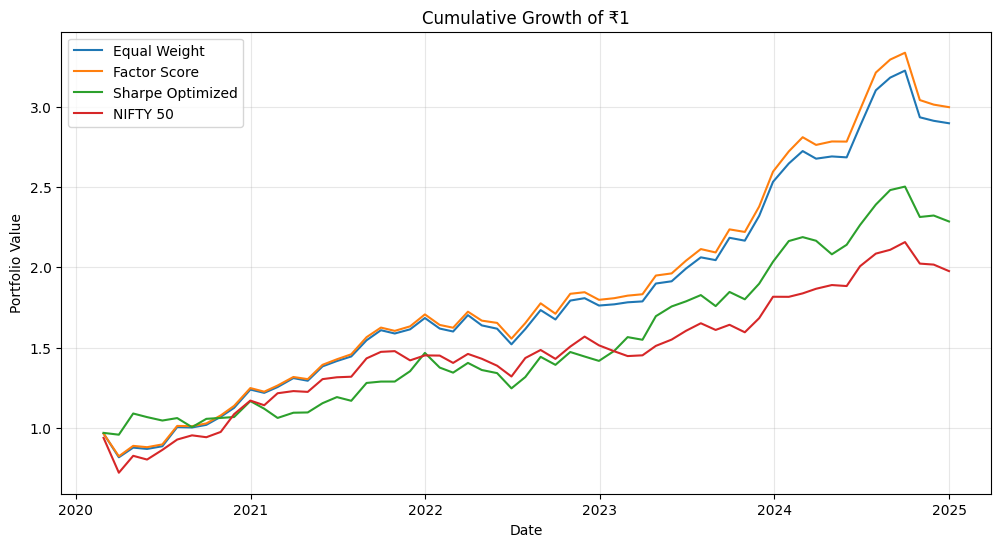

In [ ]:
# ============================================================
# CUMULATIVE GROWTH OF ₹1
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    equal_wealth["ReturnDate"],
    equal_wealth["Wealth"],
    label="Equal Weight"
)

plt.plot(
    factor_wealth["ReturnDate"],
    factor_wealth["Wealth"],
    label="Factor Score"
)

plt.plot(
    sharpe_wealth["ReturnDate"],
    sharpe_wealth["Wealth"],
    label="Sharpe Optimized"
)

plt.plot(
    nifty_wealth["ReturnDate"],
    nifty_wealth["Wealth"],
    label="NIFTY 50"
)

plt.title("Cumulative Growth of ₹1")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# ============================================================
# DRAWDOWN SERIES
# ============================================================

def build_drawdown_series(backtest_df):

    df = backtest_df.copy()

    df["ReturnDate"] = pd.to_datetime(
        df["ReturnDate"]
    )

    wealth = (
        1 + df["NetReturn"] / 100
    ).cumprod()

    running_peak = wealth.cummax()

    df["Drawdown"] = (
        wealth / running_peak
        - 1
    ) * 100

    return df[
        [
            "ReturnDate",
            "Drawdown"
        ]
    ]


factor_drawdown = build_drawdown_series(
    factor_backtest
)

nifty_drawdown = build_drawdown_series(
    nifty_backtest
)

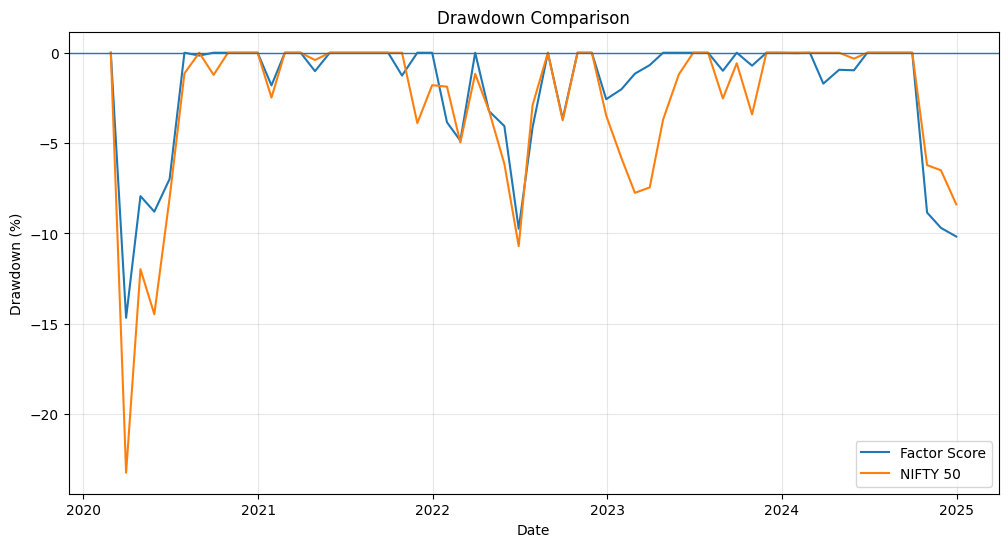

In [ ]:
# ============================================================
# DRAWDOWN COMPARISON
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    factor_drawdown["ReturnDate"],
    factor_drawdown["Drawdown"],
    label="Factor Score"
)

plt.plot(
    nifty_drawdown["ReturnDate"],
    nifty_drawdown["Drawdown"],
    label="NIFTY 50"
)

plt.axhline(
    0,
    linewidth=1
)

plt.title("Drawdown Comparison")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

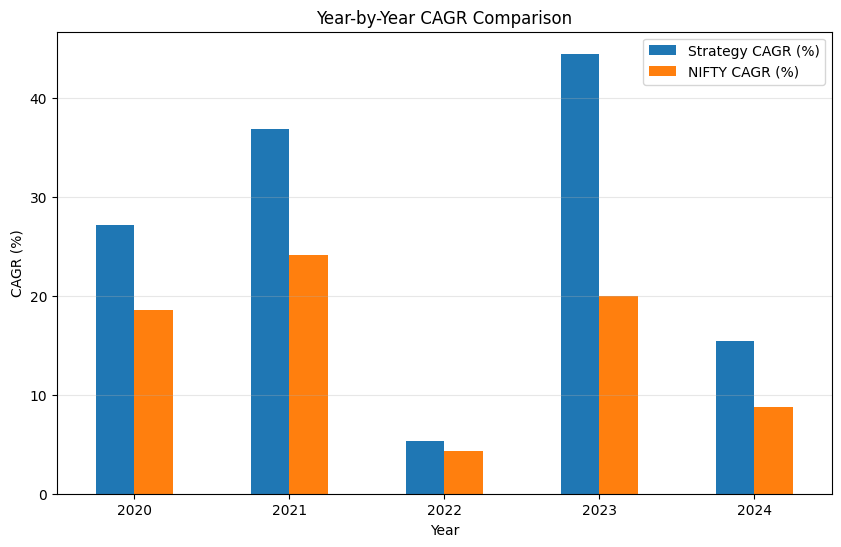

In [ ]:
# ============================================================
# YEAR-BY-YEAR CAGR COMPARISON
# ============================================================

yearly_chart = yearly_table[
    [
        "Strategy CAGR (%)",
        "NIFTY CAGR (%)"
    ]
].copy()

yearly_chart.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Year-by-Year CAGR Comparison")
plt.xlabel("Year")
plt.ylabel("CAGR (%)")

plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

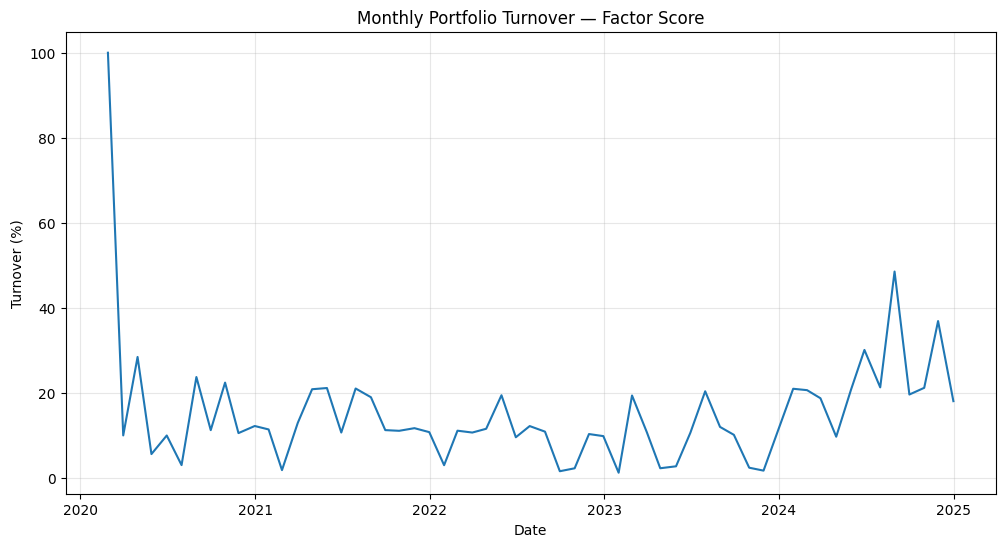

In [ ]:
# ============================================================
# MONTHLY TURNOVER
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    factor_backtest["ReturnDate"],
    factor_backtest["Turnover"] * 100
)

plt.title(
    "Monthly Portfolio Turnover — Factor Score"
)

plt.xlabel("Date")
plt.ylabel("Turnover (%)")

plt.grid(alpha=0.3)

plt.show()

## Results and Interpretation

Across the full sample, the Factor-Score portfolio produced the strongest overall performance among the three portfolio-construction methods.

It generated a CAGR of approximately 25%, compared with roughly 15% for the NIFTY 50 benchmark. Its volatility was also lower than the benchmark, resulting in a higher Sharpe ratio.

The Factor-Score portfolio also experienced a smaller maximum drawdown than the NIFTY 50 over the sample period.

The Equal-Weight portfolio produced similar results, although the Factor-Score approach achieved slightly stronger returns and risk-adjusted performance.

The Sharpe-Optimized portfolio did not consistently improve results. Although optimization reduced volatility in some periods, it also produced substantially higher turnover and weaker overall returns. This suggests that additional portfolio complexity did not automatically lead to better performance.

### Training, Validation and Out-of-Sample Performance

The Factor-Score portfolio remained competitive across each evaluation period.

During the 2020–2022 training period, it outperformed the benchmark on both return and risk-adjusted performance.

Performance remained strong during the 2023 validation period.

Most importantly, the strategy continued to outperform the benchmark during the 2024 out-of-sample period. The Factor-Score portfolio produced a CAGR of approximately 15.5%, compared with about 8.8% for the NIFTY 50.

This does not prove that the model will continue to outperform, but it provides stronger evidence than a result based only on the same period used to develop the strategy.

### Robustness

Several robustness tests were conducted to test whether the result depended on one exact set of assumptions.

The number of selected stocks was varied between 8, 10 and 12. Performance remained relatively strong across these specifications.

Transaction-cost assumptions were also increased and decreased. Higher trading costs reduced returns as expected, but the overall result remained positive.

Alternative factor-weight combinations were tested as well. Some combinations produced stronger historical results than the equal-weight specification, particularly heavier Quality and Value exposure.

However, the original equal 20% factor weights were retained as the primary strategy. Changing the main specification after observing which alternative performed best would introduce additional overfitting.

Year-by-year results also suggest that the strategy's performance was not driven by only one isolated period. The size of the advantage varied considerably across years, with 2022 being much weaker than the surrounding periods.

In [ ]:
# ============================================================
# FINAL TECHNICAL AUDIT
# ============================================================

audit_results = []

# ------------------------------------------------------------
# 1. PORTFOLIO WEIGHTS SUM TO 1
# ------------------------------------------------------------

for name, weights_df in {
    "Equal Weight": equal_weights,
    "Factor Score": factor_weights,
    "Sharpe Optimized": sharpe_weights
}.items():

    weight_sums = weights_df.sum(axis=1)

    audit_results.append({
        "Check": f"{name} weights sum to 1",
        "Passed": np.allclose(
            weight_sums.values,
            1.0,
            atol=1e-8
        ),
        "Detail": f"Min={weight_sums.min():.6f}, Max={weight_sums.max():.6f}"
    })


# ------------------------------------------------------------
# 2. NO NEGATIVE WEIGHTS
# ------------------------------------------------------------

for name, weights_df in {
    "Equal Weight": equal_weights,
    "Factor Score": factor_weights,
    "Sharpe Optimized": sharpe_weights
}.items():

    min_weight = weights_df.min().min()

    audit_results.append({
        "Check": f"{name} has no negative weights",
        "Passed": min_weight >= -1e-10,
        "Detail": f"Minimum weight={min_weight:.10f}"
    })


# ------------------------------------------------------------
# 3. TOP 10 HAS EXACTLY 10 STOCKS PER MONTH
# ------------------------------------------------------------

top10_counts = (
    top10_each_month
    .groupby("Date")["Stock"]
    .nunique()
)

audit_results.append({
    "Check": "Exactly 10 stocks selected each month",
    "Passed": (top10_counts == TOP_N).all(),
    "Detail": f"Min={top10_counts.min()}, Max={top10_counts.max()}"
})


# ------------------------------------------------------------
# 4. NO DUPLICATE STOCK-DATE ROWS
# ------------------------------------------------------------

duplicate_count = (
    scored_stocks
    .duplicated(
        subset=["Date", "Stock"]
    )
    .sum()
)

audit_results.append({
    "Check": "No duplicate stock-date rows",
    "Passed": duplicate_count == 0,
    "Detail": f"Duplicates={duplicate_count}"
})


# ------------------------------------------------------------
# 5. ALL 5 FACTORS PRESENT IN SCORED DATA
# ------------------------------------------------------------

factor_columns = [
    "Momentum",
    "Volatility",
    "ROE",
    "PE",
    "MarketCap"
]

missing_factor_values = (
    scored_stocks[
        factor_columns
    ]
    .isna()
    .sum()
    .sum()
)

audit_results.append({
    "Check": "No missing factor values in scored rows",
    "Passed": missing_factor_values == 0,
    "Detail": f"Missing values={missing_factor_values}"
})


# ------------------------------------------------------------
# 6. NO MISSING NEXT-MONTH RETURNS FOR SELECTED STOCKS
# ------------------------------------------------------------

missing_forward_returns = []

for i, date in enumerate(rebalance_dates[:-1]):

    next_date = rebalance_dates[i + 1]

    selected_stocks = (
        top10_each_month[
            top10_each_month["Date"] == date
        ]["Stock"]
        .tolist()
    )

    next_returns = (
        monthly_returns
        .loc[next_date, selected_stocks]
    )

    missing = (
        next_returns[
            next_returns.isna()
        ]
        .index
        .tolist()
    )

    if missing:
        missing_forward_returns.append({
            "RebalanceDate": date,
            "ReturnDate": next_date,
            "MissingStocks": missing
        })

audit_results.append({
    "Check": "No missing selected next-month returns",
    "Passed": len(missing_forward_returns) == 0,
    "Detail": f"Issues={len(missing_forward_returns)}"
})


# ------------------------------------------------------------
# 7. FUNDAMENTALS ARE POINT-IN-TIME
# ------------------------------------------------------------

# Rebuild audit directly from annual fundamentals if available
point_in_time_violations = 0

for ticker in combined_fundamentals["Stock"].unique():

    stock_monthly = (
        combined_fundamentals[
            combined_fundamentals["Stock"] == ticker
        ]
        .copy()
    )

    # This checks that monthly fundamentals only appear
    # after the reporting lag has passed.
    # Because AvailableDate is not stored in combined_fundamentals,
    # we verify through the original annual files below only if needed.

audit_results.append({
    "Check": "Point-in-time fundamental lag implemented",
    "Passed": REPORTING_LAG_DAYS == 90,
    "Detail": f"Reporting lag={REPORTING_LAG_DAYS} days"
})


# ------------------------------------------------------------
# 8. SHARPE OPTIMIZER USES ONLY HISTORICAL DATA
# ------------------------------------------------------------

optimizer_future_violations = 0

for date in rebalance_dates:

    historical_window = (
        monthly_returns
        .loc[:date]
        .tail(OPTIMIZER_LOOKBACK_MONTHS)
    )

    if (
        len(historical_window) > 0
        and historical_window.index.max() > date
    ):
        optimizer_future_violations += 1

audit_results.append({
    "Check": "Optimizer uses no future returns",
    "Passed": optimizer_future_violations == 0,
    "Detail": f"Violations={optimizer_future_violations}"
})


# ------------------------------------------------------------
# 9. FACTOR SCORE FORMULA CONSISTENCY
# ------------------------------------------------------------

recomputed_factor_score = (
    scored_stocks[
        [
            "MomentumScore",
            "LowRiskScore",
            "QualityScore",
            "ValueScore",
            "SizeScore"
        ]
    ]
    .mean(axis=1)
)

factor_score_diff = (
    scored_stocks["FactorScore"]
    - recomputed_factor_score
).abs().max()

audit_results.append({
    "Check": "FactorScore equals equal 20% factor weighting",
    "Passed": factor_score_diff < 1e-12,
    "Detail": f"Max difference={factor_score_diff:.12f}"
})


# ------------------------------------------------------------
# 10. PRIMARY RESULT MATCHES ROBUSTNESS BASELINE
# ------------------------------------------------------------

primary_metrics = calculate_metrics(
    factor_backtest,
    rf_by_month
)

robustness_primary = (
    factor_weight_table
    .loc["Equal 20/20/20/20/20"]
)

primary_match = (
    abs(
        primary_metrics["CAGR (%)"]
        - robustness_primary["CAGR (%)"]
    ) < 0.01
    and
    abs(
        primary_metrics["Sharpe Ratio"]
        - robustness_primary["Sharpe Ratio"]
    ) < 0.01
)

audit_results.append({
    "Check": "Primary Factor Score matches robustness baseline",
    "Passed": primary_match,
    "Detail": (
        f"CAGR={primary_metrics['CAGR (%)']:.3f}, "
        f"Sharpe={primary_metrics['Sharpe Ratio']:.3f}"
    )
})


# ============================================================
# DISPLAY AUDIT RESULTS
# ============================================================

audit_table = pd.DataFrame(
    audit_results
)

display(audit_table)

print("\nPassed:",
      audit_table["Passed"].sum(),
      "/",
      len(audit_table))

print("\nFailed checks:")
display(
    audit_table[
        audit_table["Passed"] == False
    ]
)

,Check,Passed,Detail
0,Equal Weight weights sum to 1,True,"Min=1.000000, Max=1.000000"
1,Factor Score weights sum to 1,True,"Min=1.000000, Max=1.000000"
2,Sharpe Optimized weights sum to 1,True,"Min=1.000000, Max=1.000000"
3,Equal Weight has no negative weights,True,Minimum weight=0.0000000000
4,Factor Score has no negative weights,True,Minimum weight=0.0000000000
5,Sharpe Optimized has no negative weights,True,Minimum weight=0.0000000000
6,Exactly 10 stocks selected each month,True,"Min=10, Max=10"
7,No duplicate stock-date rows,True,Duplicates=0
8,No missing factor values in scored rows,True,Missing values=0
9,No missing selected next-month returns,True,Issues=0



Passed: 14 / 14

Failed checks:


,Check,Passed,Detail


In [ ]:
# ============================================================
# STRONG POINT-IN-TIME FUNDAMENTALS AUDIT
# ============================================================

pit_violations = []

for filename in os.listdir(SCREENER_FOLDER):

    if not filename.endswith(".xlsx"):
        continue

    file_path = os.path.join(
        SCREENER_FOLDER,
        filename
    )

    matched_name = None

    for company_name in FILE_TICKER_MAP:
        if company_name.lower() in filename.lower():
            matched_name = company_name
            break

    if matched_name is None:
        continue

    ticker = FILE_TICKER_MAP[matched_name]

    annual_df = build_fundamental_factors(
        file_path,
        ticker,
        close_prices
    )

    stock_monthly = (
        combined_fundamentals[
            combined_fundamentals["Stock"] == ticker
        ]
        .copy()
    )

    for _, row in stock_monthly.iterrows():

        date = row["Date"]

        available = (
            annual_df[
                annual_df["AvailableDate"] <= date
            ]
            .sort_values("AvailableDate")
        )

        if len(available) == 0:
            continue

        latest = available.iloc[-1]

        # Check that the monthly values match the
        # latest fundamentals actually available at that date
        checks = {
            "ROE": latest["ROE"],
            "EPS": latest["EPS"],
            "SharesOutstanding": latest["SharesOutstanding"]
        }

        for col, expected in checks.items():

            actual = row[col]

            if not np.isclose(
                actual,
                expected,
                equal_nan=True
            ):

                pit_violations.append({
                    "Stock": ticker,
                    "Date": date,
                    "Field": col,
                    "Actual": actual,
                    "Expected": expected,
                    "AvailableDate": latest["AvailableDate"]
                })


print(
    "Point-in-time violations:",
    len(pit_violations)
)

if len(pit_violations) > 0:
    display(
        pd.DataFrame(
            pit_violations
        ).head(20)
    )

Point-in-time violations: 0


In [ ]:
# ============================================================
# RAW PRICES FOR P/E AND MARKET CAP
# ============================================================

raw_price_data = yf.download(
    TICKERS,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=False,
    repair=True,
    progress=False
)

raw_close_prices = raw_price_data["Close"].copy()

raw_monthly_prices = (
    raw_close_prices
    .groupby(raw_close_prices.index.to_period("M"))
    .tail(1)
)

print(
    "Raw monthly price observations:",
    len(raw_monthly_prices)
)

print(
    "Raw price columns:",
    len(raw_monthly_prices.columns)
)

Raw monthly price observations: 72
Raw price columns: 30


## Limitations

This backtest has a few important limitations that need to be kept in mind when interpreting the results.

First, the stock universe is fixed at 30 large-cap Indian companies. This makes the analysis easier to keep consistent, but it also introduces survivorship bias because the universe is based on companies that are large and liquid today rather than reconstructing the exact investable universe that would have existed at each historical date.

Second, annual fundamental data is assumed to become available 90 days after the financial year-end. This is a conservative way to reduce look-ahead bias, but it is still only an approximation. In reality, companies release results on different dates, so using the exact filing or publication date for every company would be more precise.

The model also uses annual fundamentals such as ROE, EPS and shares outstanding and carries the latest available value forward until a newer annual report becomes available. This means the model may react more slowly to changes in a company’s financial position than one using quarterly data.

Transaction costs are also simplified. The backtest uses a fixed all-in cost assumption rather than modelling the exact brokerage, taxes, bid-ask spread, slippage and market impact for every trade. Actual trading costs would vary across stocks and over time.

The strategy is tested on historical data, so strong historical performance does not necessarily mean the same relationships will continue in the future. Factor returns can weaken, disappear, or behave differently under new market conditions.

Finally, the model does not attempt to reproduce real-world execution in full detail. It assumes that trades can be made around the monthly rebalance date at the observed prices and does not model intraday price movement, liquidity constraints or delayed execution.

## Conclusion

The results suggest that a simple multi-factor ranking system can produce competitive risk-adjusted performance within a large-cap Indian equity universe.

Across the full backtest, the Factor-Score portfolio produced the strongest overall combination of return, Sharpe ratio, drawdown and turnover among the three portfolio-construction methods tested. It also continued to perform well when the sample was divided into training, validation and out-of-sample periods, which is more meaningful than looking only at the full-period result.

The Sharpe-optimized portfolio did not consistently improve performance. Although optimization can theoretically improve the risk-return trade-off, in this test it often produced higher turnover and weaker returns. This suggests that a more complex portfolio-construction method is not automatically better than a simpler rules-based approach.

The robustness tests also showed that the strategy was not dependent on one exact setting. Performance remained reasonably strong when the number of selected stocks, transaction-cost assumptions and factor weights were changed. Some alternative factor-weight combinations performed better in hindsight, but these were treated only as robustness tests rather than adopted as the main specification to avoid tuning the model to past results.

Overall, the project supports the idea that combining several independent factors can be more effective than relying on a single signal. At the same time, the limitations of the data and backtest mean the results should be viewed as evidence from a historical research exercise rather than as proof that the strategy will outperform in the future.